# Implemenation of NN Using Keras and TF

In [1]:
import tensorflow as tf # for making nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
tf.config.list_physical_devices("CPU")

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [3]:
tf.config.list_physical_devices("GPU")

[]

# Creating a simple classifier using keras on MNIST Data

In [4]:
from keras.datasets import mnist

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

In [6]:
X_train_full.shape

(60000, 28, 28)

In [7]:
X_test.shape

(10000, 28, 28)

In [8]:
X_train_full[0].shape

(28, 28)

In [9]:
X_train_full[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [10]:
print(X_train_full.max())

255


In [11]:
print(X_train_full.min())

0


## Let's scale down the values b/w 0 and 1

In [12]:
X_train_full = X_train_full/255.0


In [13]:
print(f"Max value : {X_train_full.max()}")

Max value : 1.0


In [14]:
print(f"Min value : {X_train_full.min()}")

Min value : 0.0


### Lets also scale down Testing set

In [15]:
X_test = X_test/255.0

### Lets create valdidation Data

In [16]:
X_train = X_train_full[5000:]  # only first 5k images
X_validation  = X_train_full[: 5000] # except first 5k images



In [17]:
print(f"No of training samples : {X_train.shape[0]}")
print(f"--" * 20)
print(f"No fo validation samples : {len(X_validation)}")

No of training samples : 55000
----------------------------------------
No fo validation samples : 5000


In [18]:
y_train, y_validation = y_train_full[5000: ], y_train_full[: 5000]

In [19]:
y_train.shape[0]

55000

In [20]:
y_validation.shape[0]

5000

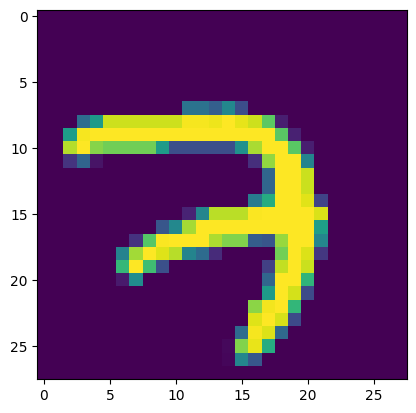

In [21]:
plt.imshow(X_train[0])
plt.show()

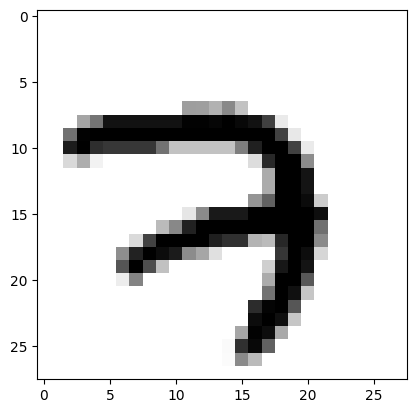

In [22]:
plt.imshow(X_train[0], cmap="binary")
plt.show()

<Axes: >

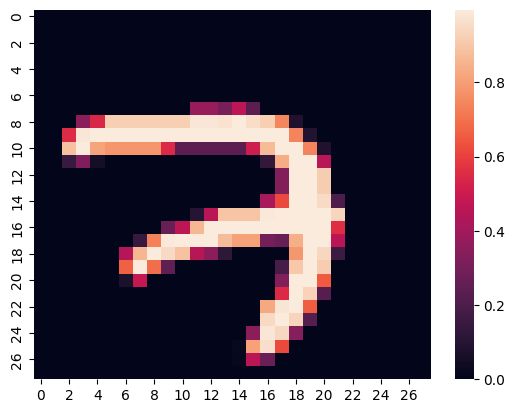

In [23]:
sns.heatmap(X_train[0])

<Axes: >

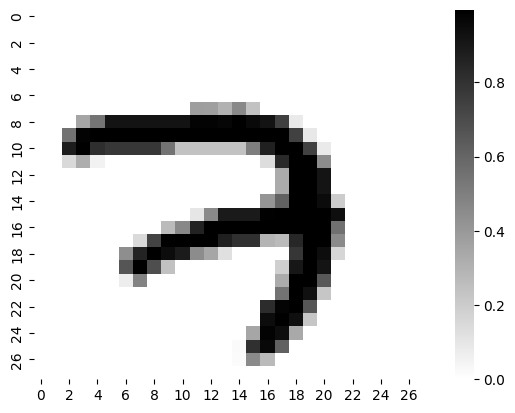

In [24]:
sns.heatmap(X_train[0], cmap='binary')

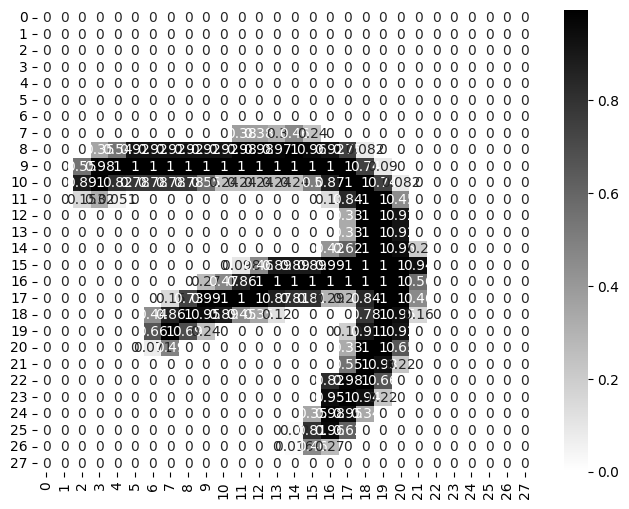

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(X_train[0], cmap='binary', annot=True)
plt.show()

In [26]:
28 * 28

784

### Creating Layers

In [27]:
Layers = [ tf.keras.layers.Flatten(input_shape=[28, 28], name="Input_Layer"),
           tf.keras.layers.Dense(300, activation="relu", name="Hidden_Layer_1"),
           tf.keras.layers.Dense(100, activation='relu', name="Hidden_Layer_2"),
           tf.keras.layers.Dense(10, activation="softmax",  name="OutPut_Layer")    # 10 units b/c we have 10 o/p classes

]


c:\Users\ok\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
from tensorflow.keras.models import Sequential

In [29]:
clf_model = Sequential(Layers)

In [30]:
clf_model.layers

[<Flatten name=Input_Layer, built=True>,
 <Dense name=Hidden_Layer_1, built=True>,
 <Dense name=Hidden_Layer_2, built=True>,
 <Dense name=OutPut_Layer, built=True>]

In [31]:
clf_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='sgd',
                  metrics=['accuracy'])

In [32]:
clf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (Flatten)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutPut_Layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## 2nd Method for Defining/Building the Model

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

In [34]:
model = Sequential() # Let's initialize the Model

In [35]:

model.add(Dense(units=300, activation="relu", input_dim=784, ))
model.add(Dense(units=100, activation="relu"))
model.add(Dense(units=10, activation="softmax"))

c:\Users\ok\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Compiling Model
model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
(300 * 784) + 300

235500

In [39]:
(100 * 300) + 100

30100

In [40]:
(10 * 100) + 10

1010

In [41]:
((300 * 784) + 300) + ((100 * 300) + 100) + ((10 * 100) + 10)

266610

### 2nd Method explicity Approch

In [69]:


model = Sequential()

model.add(Flatten(input_shape=(28, 28), name="Input_Layer"))# Explicit Flatten layer for clarity
model.add(Dense(units=300, activation="relu", name="Hidden_Layer_1"))
model.add(Dense(units=100, activation="relu", name="Hidden_Layer_2"))
model.add(Dense(units=10, activation="softmax", name="Output_Layer"))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (Flatten)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
#(neurons *  weigths)  + Bias
(300 * 784) + 300

235500

In [44]:
(100 * 300) + 100

30100

In [45]:
(10 * 100) + 10

1010

In [46]:
((300 * 784) + 300) + ((100 * 300) + 100) + ((10 * 100) + 10)

266610

In [47]:
layer = clf_model.layers[0]
layer

<Flatten name=Input_Layer, built=True>

In [48]:
layer.name

'Input_Layer'

In [49]:
layer = clf_model.layers[1]

In [50]:
layer.name

'Hidden_Layer_1'

In [51]:
hiddenLayer_1 = clf_model.layers[1]
hiddenLayer_1.name

'Hidden_Layer_1'

In [52]:
len(hiddenLayer_1.get_weights())  # two matrix 

2

In [53]:
hiddenLayer_1.get_weights()  # w,b

[array([[ 0.02793536, -0.06741365, -0.06656374, ..., -0.02485877,
          0.04217212,  0.02580216],
        [ 0.04439987, -0.03915775,  0.01820791, ...,  0.02559359,
          0.03097739,  0.05518575],
        [-0.01343671,  0.0315069 , -0.02631301, ..., -0.06858949,
          0.05226944, -0.05857584],
        ...,
        [-0.0388721 , -0.04925729,  0.02200466, ..., -0.06486529,
          0.04116378,  0.01975555],
        [ 0.06999439,  0.06633432,  0.04211552, ...,  0.05010378,
          0.03207675, -0.01424775],
        [ 0.03237335,  0.00644308,  0.06155221, ..., -0.06682245,
          0.02282307,  0.04432042]], shape=(784, 300), dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 

In [54]:
hiddenLayer_1.get_weights()[0] # ws  for each unit

array([[ 0.02793536, -0.06741365, -0.06656374, ..., -0.02485877,
         0.04217212,  0.02580216],
       [ 0.04439987, -0.03915775,  0.01820791, ...,  0.02559359,
         0.03097739,  0.05518575],
       [-0.01343671,  0.0315069 , -0.02631301, ..., -0.06858949,
         0.05226944, -0.05857584],
       ...,
       [-0.0388721 , -0.04925729,  0.02200466, ..., -0.06486529,
         0.04116378,  0.01975555],
       [ 0.06999439,  0.06633432,  0.04211552, ...,  0.05010378,
         0.03207675, -0.01424775],
       [ 0.03237335,  0.00644308,  0.06155221, ..., -0.06682245,
         0.02282307,  0.04432042]], shape=(784, 300), dtype=float32)

In [55]:
hiddenLayer_1.get_weights()[0].shape  # each unit have 784 ws

(784, 300)

In [56]:
hiddenLayer_1.get_weights()[1]  # b

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [57]:
hiddenLayer_1.get_weights()[1].shape     # (300,) is 1-d vector so each 300 unit have 1 bias

(300,)

In [58]:
histtory = clf_model.fit(
    X_train, y_train,
    validation_data= (X_validation, y_validation),
    epochs=20,
    batch_size = 30
)

Epoch 1/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8447 - loss: 0.5982 - val_accuracy: 0.9160 - val_loss: 0.3002
Epoch 2/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9188 - loss: 0.2841 - val_accuracy: 0.9328 - val_loss: 0.2386
Epoch 3/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9338 - loss: 0.2305 - val_accuracy: 0.9452 - val_loss: 0.1973
Epoch 4/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9443 - loss: 0.1960 - val_accuracy: 0.9518 - val_loss: 0.1726
Epoch 5/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9509 - loss: 0.1705 - val_accuracy: 0.9558 - val_loss: 0.1589
Epoch 6/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9569 - loss: 0.1514 - val_accuracy: 0.9582 - val_loss: 0.1440
Epoch 7/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9611 - loss: 0.1359 - val_accuracy: 0.9622 - val_loss: 0.1334
Epoch 8/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9654 - loss: 0.1228 

# Accurachy Graph

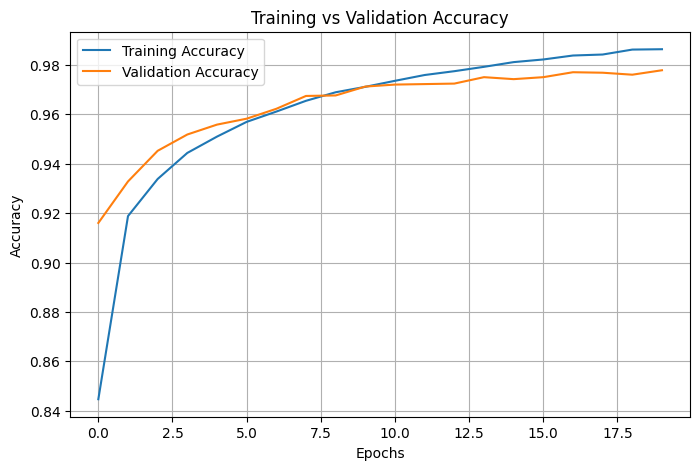

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    histtory.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    histtory.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# Traing vs Validaion Loss

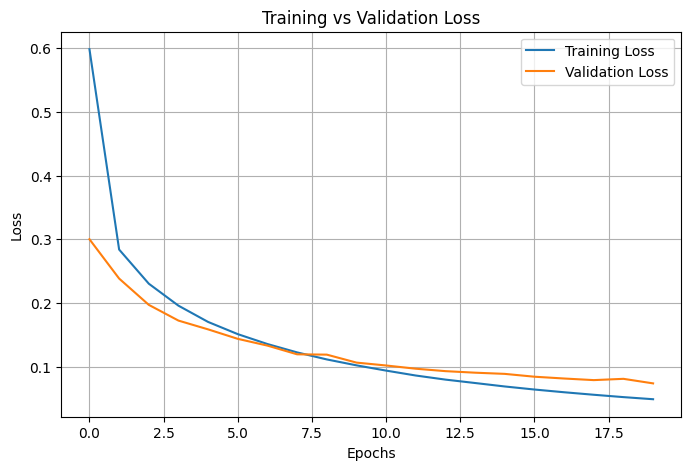

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    histtory.history["loss"],
    label="Training Loss"
)

plt.plot(
    histtory.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [65]:
from tensorflow.keras.callbacks import EarlyStopping

In [66]:
X_train.shape

(55000, 28, 28)

In [92]:
early_stopping =EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=False
)

# training the model.
histtory_2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=20,
    batch_size=30,
    callbacks=[early_stopping]
)

Epoch 1/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9991 - loss: 0.0096 - val_accuracy: 0.9802 - val_loss: 0.0712
Epoch 2/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9991 - loss: 0.0092 - val_accuracy: 0.9796 - val_loss: 0.0685
Epoch 3/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9994 - loss: 0.0087 - val_accuracy: 0.9808 - val_loss: 0.0698
Epoch 4/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9993 - loss: 0.0083 - val_accuracy: 0.9806 - val_loss: 0.0699
Epoch 5/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9993 - loss: 0.0080 - val_accuracy: 0.9792 - val_loss: 0.0709
Epoch 6/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9994 - loss: 0.0077 - val_accuracy: 0.9800 - val_loss: 0.0711
Epoch 7/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9994 - loss: 0.0073 - val_accuracy: 0.9806 - val_loss: 0.0700
Epoch 8/20
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9996 - loss: 0.0070 

In [85]:
print((histtory_2.history["loss"]))
print((histtory_2.history["accuracy"]))
print((histtory_2.history["val_loss"]))
print((histtory_2.history["val_accuracy"]))

[0.014403213746845722, 0.013670505955815315, 0.012889709323644638, 0.01237072516232729, 0.011731610633432865, 0.0110793337225914]
[0.9978908896446228, 0.9981818199157715, 0.9983999729156494, 0.9984727501869202, 0.9986363649368286, 0.99883633852005]
[0.06736933439970016, 0.0673568844795227, 0.06769982725381851, 0.06813495606184006, 0.06895259767770767, 0.06784000247716904]
[0.9801999926567078, 0.9801999926567078, 0.9797999858856201, 0.9810000061988831, 0.9800000190734863, 0.9801999926567078]


In [89]:
np.min(histtory_2.history["loss"])

np.float64(0.0110793337225914)

In [90]:
np.argmin(histtory_2.history['loss'])

np.int64(5)

In [82]:
print(len(histtory_2.history["loss"]))
print(len(histtory_2.history["accuracy"]))
print(len(histtory_2.history["val_loss"]))
print(len(histtory_2.history["val_accuracy"]))

6
6
6
6


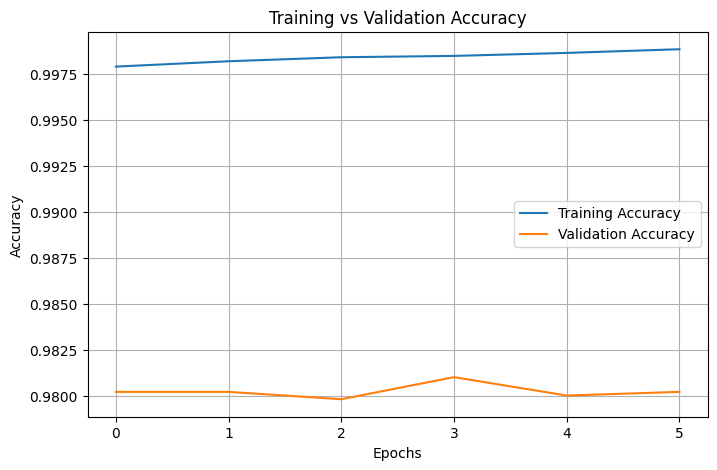

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    histtory_2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    histtory_2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

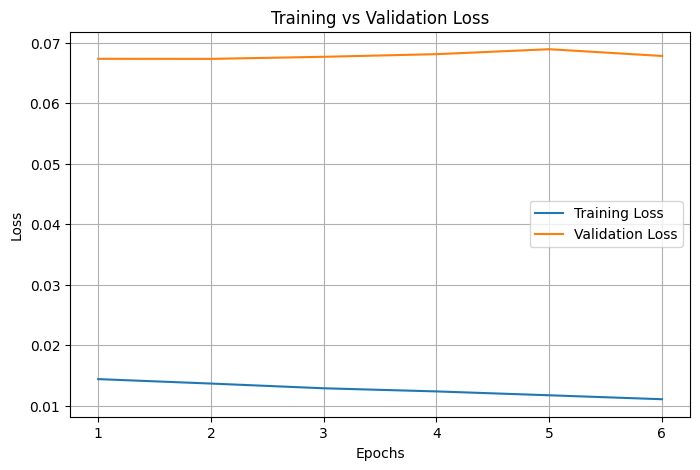

In [81]:
import matplotlib.pyplot as plt

# Create epoch numbers based on the actual training history
epochs = range(1, len(histtory_2.history["loss"]) + 1)

plt.figure(figsize=(8, 5))

# Training loss
plt.plot(
    epochs,
    histtory_2.history["loss"],
    label="Training Loss"
)

# Validation loss
plt.plot(
    epochs,
    histtory_2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:


best_val_loss = min(histtory_2.history["val_loss"])

print("Training stopped after:", len(histtory_2.history["loss"]), "epochs")

print("Best validation loss:", best_val_loss)

Training stopped after: 20 epochs
Best validation loss: 0.07415897399187088


# CNN

In [ ]:
print(np.newaxis)

In [ ]:
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [ ]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

In [ ]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

In [ ]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)